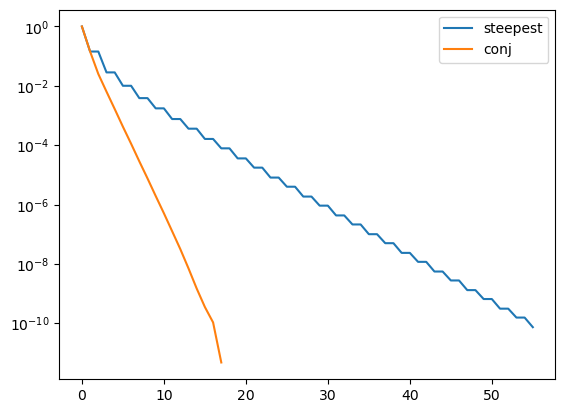

In [16]:
from scipy.io import loadmat
import numpy as np
from SolveTriangular import *
from numpy import linalg as lin
from scipy import linalg as splin
from numpy.linalg import norm
import matplotlib.pyplot as plt
from numpy.linalg import matrix_rank as rank
from itertools import takewhile

err_rel = lambda x, px: norm(x-px, 2) / norm(x, 2)
K = lambda A: norm(A) * norm(splin.inv(A))

data = loadmat('test_II.mat')
A = data['A']
A = A.astype(float)
b = data['b']
b = b.astype(float).ravel()



#A e la matrice di poisson in cui la diagnoale principale è scalata di due dunque sappiamo che
# è simmetrica e definit positiva, dunque usiamo i due metodi di discesa

def iterate(func, start):
    while True:
        yield start
        start = func(*start)

def steep(A, b, alfa, dir, toll=1e-10, itmax=1000):
    x0 = np.zeros_like(b)

    err = lambda num, den: norm(num)/norm(den)
    stop_criteria = lambda i, args: i < itmax and err(args[1], b) > toll

    def passo(x, r, p):
        a = alfa(A, r, p)
        newr = r + a * (A @ p) 
        return x + a * p, newr, dir(newr, r, p)

    r = A @ x0 - b
    
    iter = iterate(passo, (x0, r, -r))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) + [next(iter)]

    resto = [err(r, b) for x, r, p in arr]
    x_arr = [x for x, _, _ in arr]
    return x_arr[-1], len(arr), resto

def steepest(A, b):
    alfa = lambda A, r, p: -r @ p / (A @ p @ p)
    dir = lambda nr, r, p: -r
    return steep(A, b, alfa, dir)

def con_gradient(A, b):
    alfa = lambda A, r, p: r @ r / (A @ p @ p)
    def dir(nr, r, p):
        gamma = nr @ nr / (r @ r)
        return -nr + (gamma * p)
    return steep(A, b, alfa, dir)


methods = (steepest, con_gradient)

def plot(m):
    _, it, resto = m(A, b)
    plt.semilogy(range(it), resto)
    
res = [plot(m) for m in methods]
plt.legend(['steepest', 'conj'])
plt.show()

#Possiamo notare che conj converge molto piu velocemente di steepest, questo perche 

## Esercizio 2



Condizionamento di R → 4.663457775986457
Residuo → 0.0004848327762313228


Condizionamento di R → 65.67493525624792
Residuo → 0.00023646355940249814


Condizionamento di R → 18.45808953019451
Residuo → 1.2249733128901836e-05



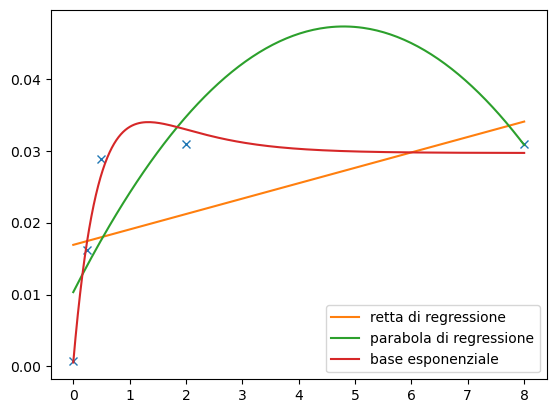

In [63]:
x = np.array([0.0004, 0.2507, 0.5008, 2.0007, 8.0013])
y = np.array([0.0007, 0.0162, 0.0288, 0.0309, 0.0310])

def plot_regression(x, y, A, meth, literal):
    xv = np.linspace(min(x), max(x), 200)
    regr = np.polyval(np.flip(meth(A, y)), xv)
    plt.plot(xv, regr, label=literal)

def plot_regression_func(x, y, A, func, meth, literal):
    xv = np.linspace(min(x), max(x), 200)
    regr = meth(A, y)
    plt.plot(xv, func(xv,*regr), label=literal)

plt.plot(x, y, 'x')

def qrLS(A, b):
    m, n = A.shape
    Q, R = splin.qr(A)
    R1 = R[:rank(A)]
    h = Q.T @ b
    print(f'\nCondizionamento di R → {lin.cond(R1)}')
    print(f'Residuo → {lin.norm(h[n:])**2}\n')
    return Usolve(R1, h[:rank(A)])


A = np.vander(x, increasing=True)[:,:2]
plot_regression(x, y, A, qrLS, 'retta di regressione')
A = np.vander(x, increasing=True)[:,:3]
plot_regression(x, y, A, qrLS, 'parabola di regressione')
A = np.ones((len(x), 3))
A[:,1] = np.exp(-x)
A[:,2] = np.exp(-2*x)
func = lambda x, a, b, c: a + b*np.exp(-x) + c*(np.exp(-2*x))
plot_regression_func(x, y, A, func, qrLS, 'base esponenziale')

plt.legend()
plt.show()

## Regressione

In [85]:
def qrLS(A, b):
    Q, R = splin.qr(A)
    R1 = R[0:n,:]
    h = Q.T @ b
    print(f'\nCondizionamento di R → {lin.cond(R1)}')
    print(f'Residuo → {lin.norm(h[n:])**2}')
    return Usolve(R1, h[0:n])

def plot_regression(x, y, A):
    xv = np.linspace(min(x), max(x), 100)
    plt.plot(x, y, 'x', label='dati sperimentali')
    alfa = svdLS(A, y)
    regression = np.polyval(np.flip(alfa), xv)
    plt.plot(xv, regression, label='qrLS')
    plt.title("Regressione")
    plt.legend()
    plt.show()

Condizionamento di A → 748849872.1584762

Diciamo che la matrice e mal condizionata e dunque non possiamo
Usare il metodo delle equazioni normali

Matrice ha rango massimo (6 == 6) e dunque qr e svdls sono utilizzabili

Metodo Singular Value Decomposition (Least Squared)
Condizionamento di A: 7.488e+08
Residuo → 0.009427272727272753


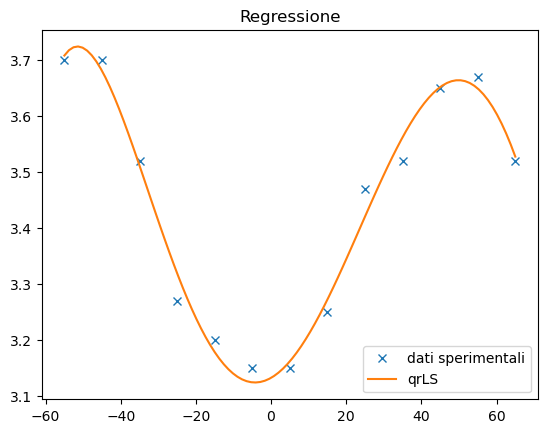

In [87]:

n = 5
A = np.vander(L, increasing=True)[:,:n+1]
m, n = A.shape
print(f'Condizionamento di A → {lin.cond(A)}\n')
print('Diciamo che la matrice e mal condizionata e dunque non possiamo\nUsare il metodo delle equazioni normali')
if rank(A) < n:
    print("\nMatrice non ha rango massimo e dunque qr e inutilizzabile")
else:
    print(f"\nMatrice ha rango massimo ({rank(A)} == {n}) e dunque qr e svdls sono utilizzabili")

plot_regression(L, T, A)
